In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,accuracy_score

import joblib

df = pd.read_csv("regressor.csv")


X = df.drop('days_since_prior_order',axis=1)
y = df['days_since_prior_order']

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2)

model = RandomForestRegressor(n_estimators=50,max_depth=10,random_state=42)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("Mean Squared Error:",mean_squared_error(y_test,y_pred))
print("R2 Score:",r2_score(y_test,y_pred))


joblib.dump(model,"random_forest_regressor.pkl")

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib

df = pd.read_csv("/content/Classifier.csv")
df.dropna(inplace=True)
X = df.drop("reordered", axis=1)

y = df["reordered"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, predictions))

print(confusion_matrix(y_test, predictions))

print(classification_report(y_test, predictions))
joblib.dump(
    model,
    "random_forest_classifier.pkl"
)

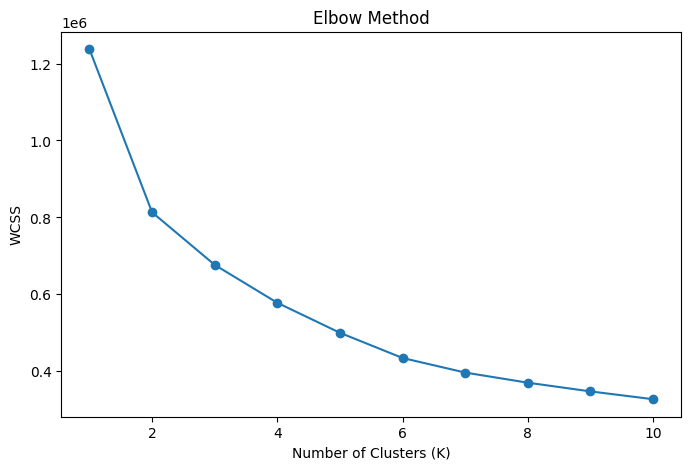

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("/content/K-means Dataset.csv")

X = df.drop("user_id", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [ ]:
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("K-means Dataset.csv")


if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

X = df.drop(columns=["user_id"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ kmeans_model.pkl saved")
print("✅ scaler.pkl saved")